<a href="https://colab.research.google.com/github/fralfaro/MAT306/blob/main/docs/labs/lab_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MAT306 - Laboratorio N°06


**Objetivo**: Aplicar técnicas básicas de **Machine Learning**, desde la preparación de datos hasta el entrenamiento y evaluación de modelos.




<p align="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/e/ec/Anscombe%27s_quartet_3.svg/1200px-Anscombe%27s_quartet_3.svg.png" width="500"/>
</p>

El **cuarteto de Anscombe** es un ejemplo clásico en estadística que ilustra cómo diferentes conjuntos de datos pueden compartir las mismas propiedades estadísticas, como media, varianza y correlación, pero presentan comportamientos muy distintos cuando se visualizan gráficamente. Cada uno de los cuatro conjuntos consiste en once puntos (x, y) y fue creado por el estadístico F. J. Anscombe en 1973. Esta herramienta resalta la importancia de la visualización de datos para evitar interpretaciones erróneas basadas únicamente en análisis numéricos.

**Descripción del conjunto**

1. **Propiedades estadísticas comunes:** Todos los conjuntos tienen el mismo valor promedio para las variables \(x\) e \(y\), la misma varianza para \(x\) e \(y\), y una correlación lineal idéntica.
2. **Diferencias gráficas:** A pesar de sus similitudes estadísticas, los cuatro conjuntos presentan gráficos muy distintos:
   - El primer conjunto muestra una relación lineal simple.
   - El segundo conjunto tiene una relación no lineal, con una curva clara.
   - El tercer conjunto tiene una relación lineal clara, pero con un punto atípico que influye significativamente.
   - El cuarto conjunto tiene la mayoría de los puntos alineados verticalmente, con un punto atípico que afecta la correlación.

Este cuarteto enfatiza que las estadísticas descriptivas por sí solas pueden no capturar la esencia completa de los datos, subrayando la necesidad de utilizar visualizaciones en cualquier análisis exploratorio de datos.

In [8]:
# Importar las bibliotecas necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")

# Configuración de los gráficos
%matplotlib inline
sns.set_theme(style="whitegrid")  # Establece un tema general para los gráficos
sns.set_palette("deep", desat=0.6)
plt.rcParams['figure.figsize'] = (12, 8)  # Ajuste del tamaño de las figuras

# Cargar los datos del cuarteto de Anscombe
data = sns.load_dataset("anscombe")

# Mostrar las primeras filas del conjunto de datos
data.head()

,dataset,x,y
0,I,10.0,8.04
1,I,8.0,6.95
2,I,13.0,7.58
3,I,9.0,8.81
4,I,11.0,8.33


Con base en la información presentada y el análisis realizado, les invitamos a reflexionar y responder las siguientes preguntas. Estas preguntas están diseñadas para profundizar en su comprensión del cuarteto de Anscombe y fomentar un análisis crítico de los datos:



1. Cree un gráfico de dispersión (scatter plot) para cada uno de los cuatro grupos del cuarteto de Anscombe. A partir de la visualización, ¿puede identificar diferencias significativas entre los grupos? ¿Qué características particulares observa en cada uno que sugieren comportamientos distintos?



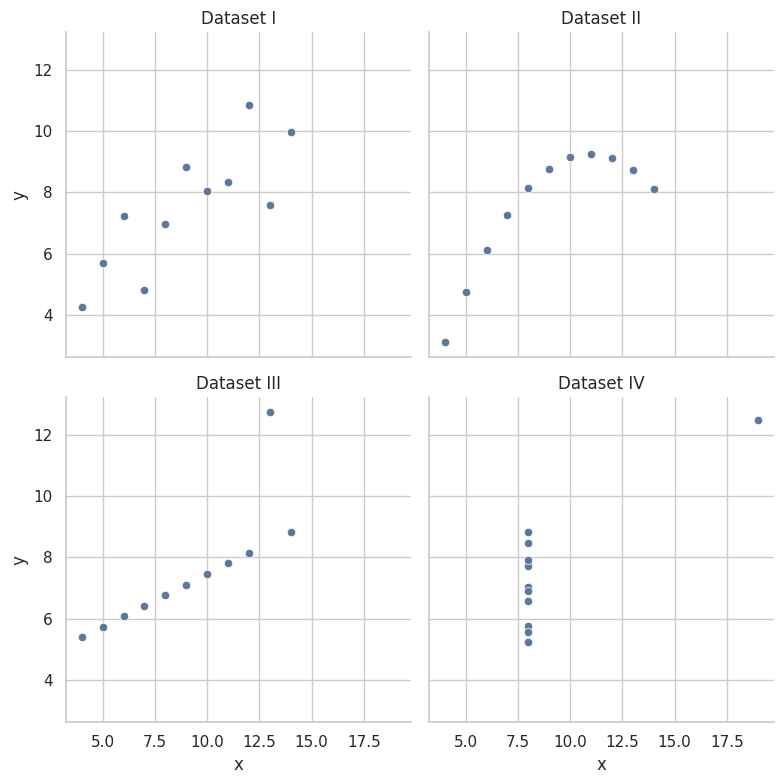

In [9]:
# Crear un gráfico de dispersión para cada grupo
g = sns.FacetGrid(data, col="dataset", col_wrap=2, height=4)
g.map(sns.scatterplot, "x", "y")
g.set_titles("Dataset {col_name}")
plt.tight_layout()
plt.show()

# Reflexión:
# Observando los gráficos, se pueden identificar diferencias significativas entre los grupos a pesar de tener estadísticas descriptivas similares.
# - Dataset I: Presenta una relación lineal clara.
# - Dataset II: Muestra una relación no lineal, con una forma curva, podriamos decir con seguridad que es una cuadratica.
# - Dataset III: Parece tener una relación lineal, pero con un punto atípico que se desvía de la tendencia general.
# - Dataset IV: La mayoría de los puntos están agrupados en una línea vertical, con un punto atípico que influye en la correlación.

2. Utilice el comando `describe` para generar un resumen de las medidas estadísticas más relevantes para cada uno de los grupos del cuarteto de Anscombe. A partir de estos resultados, interprete las estadísticas obtenidas, destacando las características más significativas de cada grupo y cómo pueden influir en la comprensión de sus respectivas distribuciones.


In [10]:
print("Resumen estadistico para cada dataset")
print(data.groupby('dataset').describe())

Resumen estadistico para cada dataset
            x                                               y            \
        count mean       std  min  25%  50%   75%   max count      mean   
dataset                                                                   
I        11.0  9.0  3.316625  4.0  6.5  9.0  11.5  14.0  11.0  7.500909   
II       11.0  9.0  3.316625  4.0  6.5  9.0  11.5  14.0  11.0  7.500909   
III      11.0  9.0  3.316625  4.0  6.5  9.0  11.5  14.0  11.0  7.500000   
IV       11.0  9.0  3.316625  8.0  8.0  8.0   8.0  19.0  11.0  7.500909   

                                                   
              std   min    25%   50%   75%    max  
dataset                                            
I        2.031568  4.26  6.315  7.58  8.57  10.84  
II       2.031657  3.10  6.695  8.14  8.95   9.26  
III      2.030424  5.39  6.250  7.11  7.98  12.74  
IV       2.030579  5.25  6.170  7.04  8.19  12.50  


3. Ajuste un modelo de regresión lineal para cada grupo utilizando **sklearn**. Calcule las métricas de evaluación, como el error cuadrático medio (MSE) y R², y grafique los resultados de la regresión. Interprete los resultados y su impacto en la calidad del ajuste.



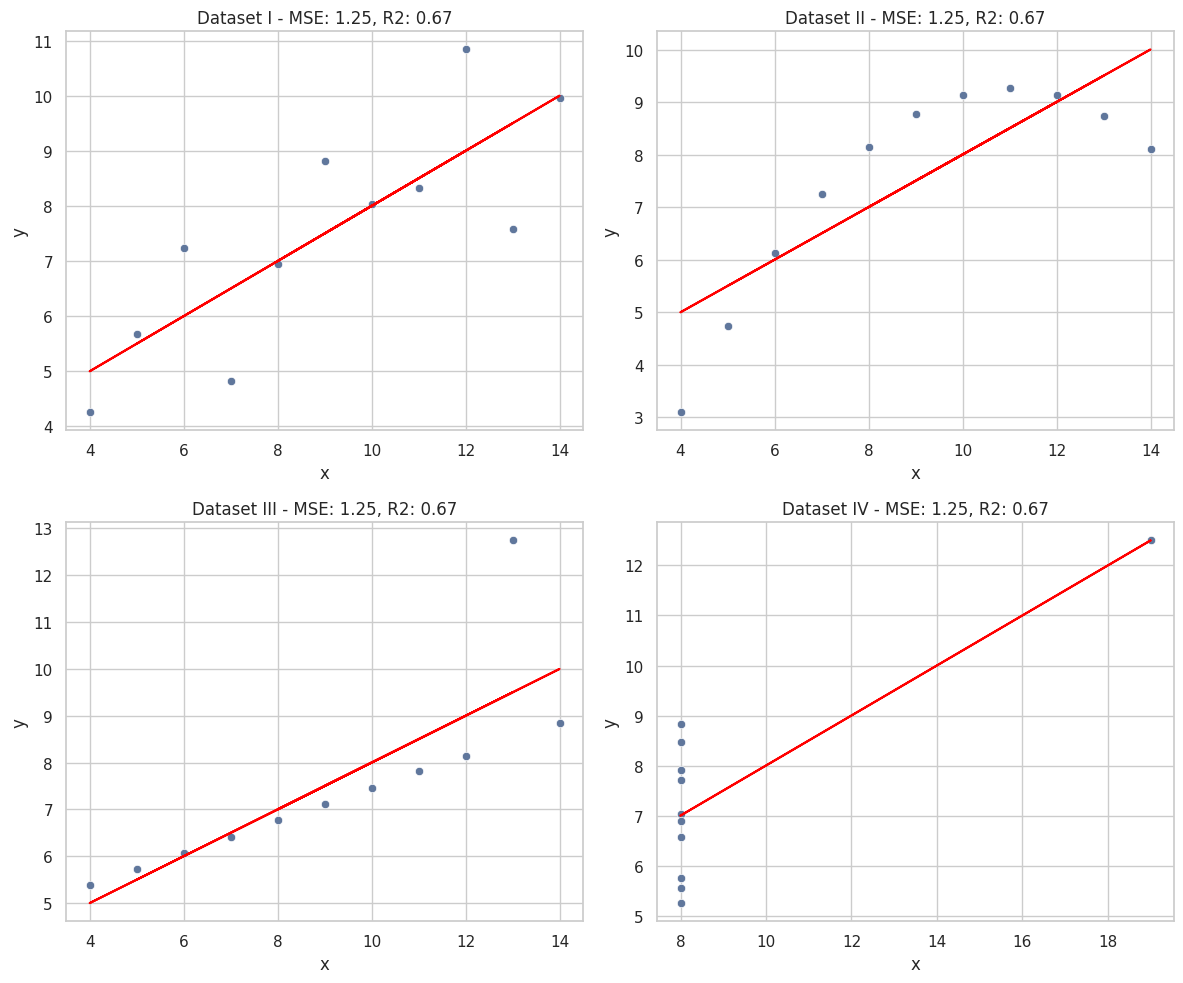

Resultados de la regresión lineal para cada dataset:
Dataset I:
  Coeficiente (slope): 0.50
  Intercepto: 3.00
  Error cuadrático medio (MSE): 1.25
  R²: 0.67
--------------------
Dataset II:
  Coeficiente (slope): 0.50
  Intercepto: 3.00
  Error cuadrático medio (MSE): 1.25
  R²: 0.67
--------------------
Dataset III:
  Coeficiente (slope): 0.50
  Intercepto: 3.00
  Error cuadrático medio (MSE): 1.25
  R²: 0.67
--------------------
Dataset IV:
  Coeficiente (slope): 0.50
  Intercepto: 3.00
  Error cuadrático medio (MSE): 1.25
  R²: 0.67
--------------------


In [7]:
# Ajustar un modelo de regresión lineal para cada grupo y calcular métricas
datasets = data['dataset'].unique()
results = {}

plt.figure(figsize=(12, 10))

for i, dataset in enumerate(datasets):
    subset = data[data['dataset'] == dataset]
    X = subset[['x']]
    y = subset['y']

    # Ajustar el modelo de regresión lineal
    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)

    # Calcular métricas de evaluación
    mse = mean_squared_error(y, y_pred)
    r2 = r2_score(y, y_pred)

    results[dataset] = {'MSE': mse, 'R2': r2, 'model': model}

    # Graficar los resultados
    plt.subplot(2, 2, i + 1)
    sns.scatterplot(x='x', y='y', data=subset)
    plt.plot(X, y_pred, color='red')
    plt.title(f'Dataset {dataset} - MSE: {mse:.2f}, R2: {r2:.2f}')
    plt.xlabel('x')
    plt.ylabel('y')

plt.tight_layout()
plt.show()

# Interpretar los resultados
print("Resultados de la regresión lineal para cada dataset:")
for dataset, metrics in results.items():
    print(f"Dataset {dataset}:")
    print(f"  Coeficiente (slope): {metrics['model'].coef_[0]:.2f}")
    print(f"  Intercepto: {metrics['model'].intercept_:.2f}")
    print(f"  Error cuadrático medio (MSE): {metrics['MSE']:.2f}")
    print(f"  R²: {metrics['R2']:.2f}")
    print("-" * 20)

# Reflexión:
# A pesar de que las métricas (MSE y R²) son iguales para los cuatro datasets, los gráficos de regresión muestran claramente que el ajuste lineal solo es adecuado para el Dataset I.
# En el Dataset II, la relación es no lineal y la línea de regresión no captura la forma de los datos.
# En el Dataset III, el punto atípico influye fuertemente en la línea de regresión.
# En el Dataset IV, la mayoría de los puntos están agrupados verticalmente y la línea de regresión es casi horizontal, afectada por el punto atípico.
# Esto refuerza la idea de que las métricas pueden ser engañosas y la visualización es necesaria para entender la relación entre las variables.

4. Es evidente que el ajuste lineal no es adecuado para algunos grupos. Existen diversas estrategias para abordar este problema, como eliminar outliers o emplear diferentes modelos de regresión. Identifique una estrategia que podría mejorar el ajuste del modelo de regresión lineal y, si lo considera necesario, implemente otros modelos alternativos para aquellos casos donde el ajuste lineal resulte inadecuado.

Ajustando Regresion Polinomial para Dataset II:
  Error cuadrático medio (MSE) - Regresion Polinomial: 0.00
  R² - Regresion Polinomial: 1.00


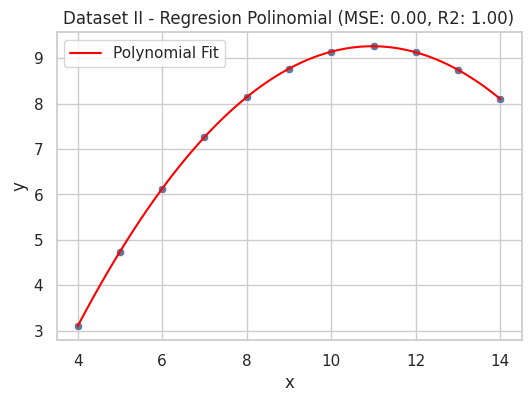


Quitando outlinear para Dataset III:
  Identificar el outlier: {'dataset': 'III', 'x': 13.0, 'y': 12.74}
  Error cuadrático medio (MSE) - Regresion lineal (sin outlinear): 0.00
  R² - Regresion lineal (sin outlinear): 1.00
  Coeficiente (slope) - Regresion lineal (sin outlinear): 0.35
  Intercepto - Regresion lineal (sin outlinear): 4.01


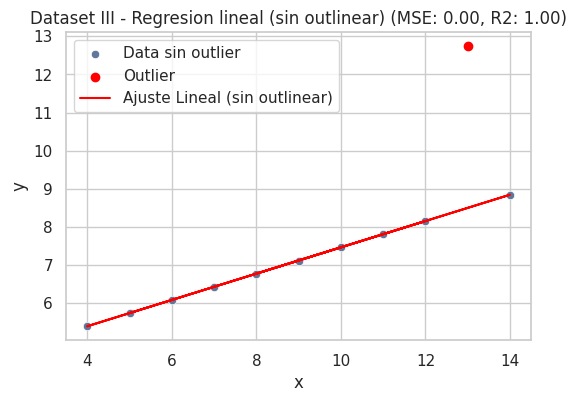


Quitando outlinear para Dataset IV:
  Identificar el outlier: {'dataset': 'IV', 'x': 19.0, 'y': 12.5}
  Error cuadrático medio (MSE) - Regresion lineal (sin outlinear): 1.37
  R² - Regresion lineal (sin outlinear): 0.00
  Coeficiente (slope) - Regresion lineal (sin outlinear): 0.00
  Intercepto - Regresion lineal (sin outlinear): 7.00


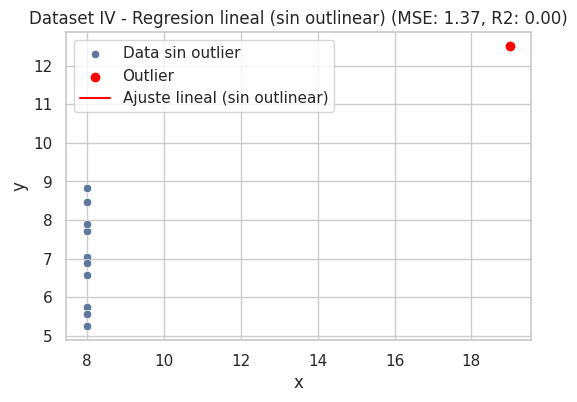

In [14]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline


# Dataset II:
print("Ajustando Regresion Polinomial para Dataset II:")
subset_II = data[data['dataset'] == 'II']
X_II = subset_II[['x']]
y_II = subset_II['y']

# Consideramos una curva cuadratica para ajustar los datos
model_poly = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
model_poly.fit(X_II, y_II)
y_pred_poly = model_poly.predict(X_II)

mse_poly = mean_squared_error(y_II, y_pred_poly)
r2_poly = r2_score(y_II, y_pred_poly)

print(f"  Error cuadrático medio (MSE) - Regresion Polinomial: {mse_poly:.2f}")
print(f"  R² - Regresion Polinomial: {r2_poly:.2f}")

plt.figure(figsize=(6, 4))
sns.scatterplot(x='x', y='y', data=subset_II)
x_range = np.linspace(X_II['x'].min(), X_II['x'].max(), 100).reshape(-1, 1)
y_pred_range = model_poly.predict(x_range)
plt.plot(x_range, y_pred_range, color='red', label='Polynomial Fit')
plt.title(f'Dataset II - Regresion Polinomial (MSE: {mse_poly:.2f}, R2: {r2_poly:.2f})')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()


# For Dataset III:
print("\nQuitando outlinear para Dataset III:")
subset_III = data[data['dataset'] == 'III'].copy()

# Identificamos el outlier
outlier_index = subset_III['y'].idxmax()
outlier_point = subset_III.loc[outlier_index]
print(f"  Identificar el outlier: {outlier_point.to_dict()}")

# Lo quitamos para ajecutar la regresion
subset_III_cleaned = subset_III.drop(outlier_index)

X_III_cleaned = subset_III_cleaned[['x']]
y_III_cleaned = subset_III_cleaned['y']

# Ajustamos la recta
model_linear_cleaned = LinearRegression()
model_linear_cleaned.fit(X_III_cleaned, y_III_cleaned)
y_pred_linear_cleaned = model_linear_cleaned.predict(X_III_cleaned)

mse_linear_cleaned = mean_squared_error(y_III_cleaned, y_pred_linear_cleaned)
r2_linear_cleaned = r2_score(y_III_cleaned, y_pred_linear_cleaned)

print(f"  Error cuadrático medio (MSE) - Regresion lineal (sin outlinear): {mse_linear_cleaned:.2f}")
print(f"  R² - Regresion lineal (sin outlinear): {r2_linear_cleaned:.2f}")
print(f"  Coeficiente (slope) - Regresion lineal (sin outlinear): {model_linear_cleaned.coef_[0]:.2f}")
print(f"  Intercepto - Regresion lineal (sin outlinear): {model_linear_cleaned.intercept_:.2f}")

plt.figure(figsize=(6, 4))
sns.scatterplot(x='x', y='y', data=subset_III_cleaned, label='Data sin outlier')
plt.scatter(outlier_point['x'], outlier_point['y'], color='red', label='Outlier') # Plot the outlier
plt.plot(X_III_cleaned, y_pred_linear_cleaned, color='red', label='Ajuste Lineal (sin outlinear)')
plt.title(f'Dataset III - Regresion lineal (sin outlinear) (MSE: {mse_linear_cleaned:.2f}, R2: {r2_linear_cleaned:.2f})')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()


# For Dataset IV:
print("\nQuitando outlinear para Dataset IV:")
subset_IV = data[data['dataset'] == 'IV'].copy()

# Identificamos el outlier
outlier_index_IV = subset_IV['x'].idxmax()
outlier_point_IV = subset_IV.loc[outlier_index_IV]
print(f"  Identificar el outlier: {outlier_point_IV.to_dict()}")

# Lo quitamos para hacer la regresion
subset_IV_cleaned = subset_IV.drop(outlier_index_IV)

X_IV_cleaned = subset_IV_cleaned[['x']]
y_IV_cleaned = subset_IV_cleaned['y']

# Creamos la recta que mejor se ajusta
model_linear_cleaned_IV = LinearRegression()
model_linear_cleaned_IV.fit(X_IV_cleaned, y_IV_cleaned)
y_pred_linear_cleaned_IV = model_linear_cleaned_IV.predict(X_IV_cleaned)

mse_linear_cleaned_IV = mean_squared_error(y_IV_cleaned, y_pred_linear_cleaned_IV)
r2_linear_cleaned_IV = r2_score(y_IV_cleaned, y_pred_linear_cleaned_IV)

print(f"  Error cuadrático medio (MSE) - Regresion lineal (sin outlinear): {mse_linear_cleaned_IV:.2f}")
print(f"  R² - Regresion lineal (sin outlinear): {r2_linear_cleaned_IV:.2f}")
print(f"  Coeficiente (slope) - Regresion lineal (sin outlinear): {model_linear_cleaned_IV.coef_[0]:.2f}")
print(f"  Intercepto - Regresion lineal (sin outlinear): {model_linear_cleaned_IV.intercept_:.2f}")


plt.figure(figsize=(6, 4))
sns.scatterplot(x='x', y='y', data=subset_IV_cleaned, label='Data sin outlier')
plt.scatter(outlier_point_IV['x'], outlier_point_IV['y'], color='red', label='Outlier') # Plot the outlier
plt.plot(X_IV_cleaned, y_pred_linear_cleaned_IV, color='red', label='Ajuste lineal (sin outlinear)')
plt.title(f'Dataset IV - Regresion lineal (sin outlinear) (MSE: {mse_linear_cleaned_IV:.2f}, R2: {r2_linear_cleaned_IV:.2f})')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

# For Dataset I:
# Es una regresion lineal por lo tanto no necesitamos hacer nada extra para este Dataset.